# Assignment 5, Question 7: Group Operations & Final Analysis

**Points: 15**

Perform grouped analysis and create summary reports.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import utilities
from q3_data_utils import load_data, summarize_by_group

df = load_data('data/clinical_trial_raw.csv')
print(f"Loaded {len(df)} patients")

# Prewritten visualization function for grouped analysis
def plot_group_comparison(data, x_col, y_col, title):
    """
    Create a bar chart comparing groups.
    
    Args:
        data: DataFrame with grouped data
        x_col: Column name for x-axis (groups)
        y_col: Column name for y-axis (values)
        title: Chart title
    """
    plt.figure(figsize=(10, 6))
    data.plot(x=x_col, y=y_col, kind='bar')
    plt.title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Loaded 10000 patients


## Part 1: Basic Groupby (5 points)

1. Group by 'site' and calculate mean age, BMI, and blood pressure
2. Group by 'intervention_group' and count patients
3. Use the `summarize_by_group()` utility to get overall statistics by site

In [2]:
# TODO: Group by site
df.columns
df['site'] = df['site'].str.strip().str.lower().str.replace("_"," ").str.replace("  ", " ")
df.groupby('site')[['age','bmi', 'systolic_bp', 'diastolic_bp']].agg(['mean'])

,age,bmi,systolic_bp,diastolic_bp
,mean,mean,mean,mean
site,,,,
site a,56.364005,25.875183,117.354284,73.549508
site b,62.401957,25.706681,117.130675,73.310140
site c,57.312108,25.789583,117.978359,73.676397
site d,63.491006,25.565682,117.943662,73.639437
site e,57.064897,25.476502,117.503080,73.752567


In [3]:
# TODO: Count by intervention group
print(df['intervention_group'].unique())
df['intervention_group'] = df['intervention_group'].str.strip().str.lower().str.replace("contrl","control").str.replace("treatmen a", "treatment a").str.replace("treatmenta", "treatment a").str.replace('treatment  b','treatment b')
df.groupby('intervention_group').agg(['count'])

['Control' 'CONTROL' '  treatment b  ' 'treatment b' 'Treatmen A'
 'TreatmentA' 'treatment a' 'TREATMENT A' 'Treatment B' 'control' 'Contrl'
 'Treatment A' 'TREATMENT B' '  control  ' '  TREATMENT A  '
 'Treatment  B' '  TreatmentA  ' '  Contrl  ' '  TREATMENT B  '
 '  treatment a  ' '  Control  ' '  Treatmen A  ' '  Treatment  B  '
 '  Treatment A  ' '  Treatment B  ' '  CONTROL  ']


,patient_id,age,sex,bmi,enrollment_date,systolic_bp,diastolic_bp,cholesterol_total,cholesterol_hdl,cholesterol_ldl,glucose_fasting,site,follow_up_months,adverse_events,outcome_cvd,adherence_pct,dropout
,count,count,count,count,count,count,count,count,count,count,count,count,count,count,count,count,count
intervention_group,,,,,,,,,,,,,,,,,
control,3337,3337,3337,3193,3337,3210,3210,3145,3145,3145,3212,3337,3337,3337,3337,2831,3337
treatment a,3321,3321,3321,3182,3321,3181,3181,3141,3141,3141,3190,3321,3321,3321,3321,2831,3321
treatment b,3342,3342,3342,3187,3342,3195,3195,3160,3160,3160,3229,3342,3342,3342,3342,2871,3342


**Note:** The `summarize_by_group()` function has an optional `agg_dict` parameter for custom aggregations. If you don't specify it, it will use `.describe()` on numeric columns. You can use `agg_dict={'age': ['mean', 'std'], 'bmi': 'mean'}` for custom aggregations.


In [4]:
# TODO: Use summarize_by_group utility
agg_dict = {
    'age': ['mean', 'std'],
    'bmi': ['mean', 'std'],
    'systolic_bp': ['mean', 'std']
 }
summary = summarize_by_group(df,'site', agg_dict = agg_dict)
print(summary)

              age                    bmi           systolic_bp           
             mean         std       mean       std        mean        std
site                                                                     
site a  56.364005  162.536292  25.875183  4.983102  117.354284  14.109332
site b  62.401957  139.050180  25.706681  5.017423  117.130675  13.532200
site c  57.312108  157.941868  25.789583  5.417217  117.978359  13.974010
site d  63.491006  136.140058  25.565682  5.881319  117.943662  13.906298
site e  57.064897  157.697644  25.476502  6.084532  117.503080  14.696501


## Part 2: Multiple Aggregations (5 points)

Group by 'site' and apply multiple aggregations:
- age: mean, std, min, max
- bmi: mean, std
- systolic_bp: mean, median

Display the results in a well-formatted table.

In [5]:
# TODO: Multiple aggregations
agg_dic = ({
           'age': ['mean', 'std', 'min', 'max'],
           'bmi': ['mean', 'std'],
           'systolic_bp': ['mean', 'median']
        })


site_summary = df.groupby('site').agg(agg_dic)
display(summary)

age                    bmi           systolic_bp           
             mean         std       mean       std        mean        std
site                                                                     
site a  56.364005  162.536292  25.875183  4.983102  117.354284  14.109332
site b  62.401957  139.050180  25.706681  5.017423  117.130675  13.532200
site c  57.312108  157.941868  25.789583  5.417217  117.978359  13.974010
site d  63.491006  136.140058  25.565682  5.881319  117.943662  13.906298
site e  57.064897  157.697644  25.476502  6.084532  117.503080  14.696501

## Part 3: Comparative Analysis (5 points)

Compare intervention groups:
1. Calculate mean outcome_cvd rate by intervention_group
2. Calculate mean adherence_pct by intervention_group
3. Create a cross-tabulation of intervention_group vs dropout status
4. Visualize the comparison with a bar plot

In [6]:
# TODO: Intervention group comparisons
df.columns
df['outcome_cvd'].head()
print(df['outcome_cvd'].unique())
df['outcome_cvd'] = df['outcome_cvd'].replace('no', 0).replace('yes',1).replace('Yes', 1).replace('No', 0)
print(f"first five lines:\n{df['outcome_cvd'].head()}")
result1 = df.groupby('intervention_group').agg(outcome_cvd_mean=('outcome_cvd', 'mean')).reset_index()
result2 = df.groupby('intervention_group').agg(adherence_pct_mean=('adherence_pct', 'mean')).reset_index()

print(f"{result1}\n")
print(f"{result2}\n")

crosstable = pd.crosstab(df['intervention_group'],df['dropout'])
print(crosstable)

['No' 'Yes' 'yes' 'no']
first five lines:
0    0
1    0
2    1
3    0
4    1
Name: outcome_cvd, dtype: int64
  intervention_group  outcome_cvd_mean
0            control          0.336530
1        treatment a          0.319482
2        treatment b          0.333633

  intervention_group  adherence_pct_mean
0            control           60.621688
1        treatment a           60.210173
2        treatment b           61.009404

dropout               No  Yes
intervention_group           
control             2831  506
treatment a         2831  490
treatment b         2871  471


/var/folders/_w/38ks4pz11gsfp199fkrfq29w0000gn/T/ipykernel_85915/4110114170.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['outcome_cvd'] = df['outcome_cvd'].replace('no', 0).replace('yes',1).replace('Yes', 1).replace('No', 0)


<Figure size 1000x600 with 0 Axes>

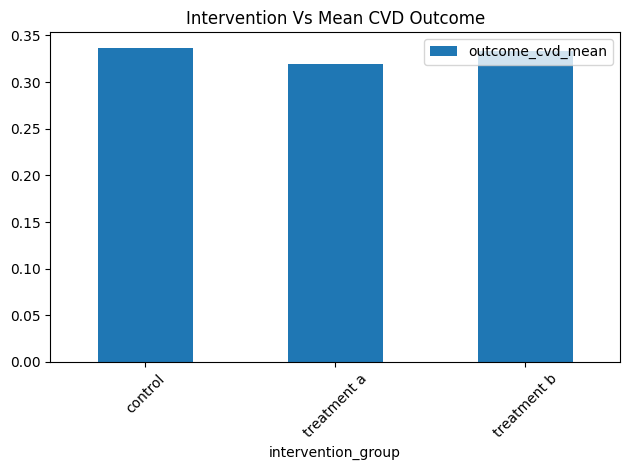

<Figure size 1000x600 with 0 Axes>

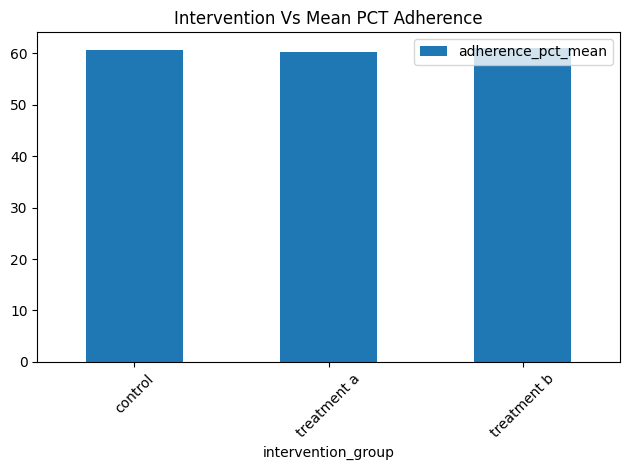

In [7]:
# TODO: Visualization
def plot_group_comparison(data, x_col, y_col, title):
    """
    Create a bar chart comparing groups.
    
    Args:
        data: DataFrame with grouped data
        x_col: Column name for x-axis (groups)
        y_col: Column name for y-axis (values)
        title: Chart title
    """
    plt.figure(figsize=(10, 6))
    data.plot(x=x_col, y=y_col, kind='bar')
    plt.title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
plot_group_comparison(data = result1, x_col = 'intervention_group', y_col = 'outcome_cvd_mean', title= 'Intervention Vs Mean CVD Outcome')
plot_group_comparison(data = result2, x_col = 'intervention_group', y_col = 'adherence_pct_mean', title= 'Intervention Vs Mean PCT Adherence')


## Part 4: Final Report

Create and save:
1. Summary statistics by site → `output/q7_site_summary.csv`
2. Intervention group comparison → `output/q7_intervention_comparison.csv`
3. Text report with key findings → `output/q7_analysis_report.txt`

In [8]:
# TODO: Save summary outputs
site_summary.to_csv('output/q7_site_summary.csv')
intervention_comparison = pd.merge(result1,result2,on = 'intervention_group')
intervention_comparison.to_csv('output/q7_intervention_comparison.csv')
analysis_text = f"""
    ====REPORT====
    --------------
    Site Summary:
    {site_summary.to_string(index = False)}\n
    Invervention Group Comparison:
    {intervention_comparison.to_string(index=False)}"""

with open('output/q7_analysis_report.txt', 'w') as f:
    f.write(analysis_text)

## Summary

What are the 3 most important findings from your analysis?

**Key Findings:**

1. There was similar adherence across all treatment groups
2. Treatment A had lowest amount of cases of CVD with a mean of 0.319482
3. Across the sites the summary statistics were very similar which is good except for age which was more varied across the sites
